In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sebastianvpal/statics-part0/min_Y_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/max_X_vertical_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/max_Y_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/max_X_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/std_Y_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/std_X_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/std_Y_vertical_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/min_Y_vertical_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/std_X_vertical_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/max_Y_vertical_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/min_X_vertical_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/mean_Y_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/min_X_part0.npy
/kaggle/input/datasets/sebastianvpal/statics-part0/mean_X_vertical_part0.n

# Read the statistics obtained with chunks and combine them to obtain the global statistics

In [1]:
import numpy as np
import polars as pl

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_vertical_stats(mean_out, std_out, min_out, max_out, var_names=None, n_levels=60, cols_in=None):
    """
    Plots vertical profile statistics (mean, std, min, max) for each variable.
    One figure per variable, showing all 60 vertical levels on the Y axis.

    Args:
        mean_out  : list of length n_vars, each element is a scalar (global mean per var)
                    OR list of length n_vars where each element has n_levels values
        std_out   : same structure as mean_out
        min_out   : same structure
        max_out   : same structure
        var_names : list of variable names (e.g. ['state_q0001', ...]). If None, uses var_0..var_N
        n_levels  : number of vertical levels (default 60)
        cols_in   : original column list (used to infer per-level values if needed)
    """

    n_vars = len(mean_out)
    if var_names is None:
        var_names = [f"var_{i}" for i in range(n_vars)]

    # --- Color palette ---
    C_MEAN = "#2196F3"   # blue
    C_STD  = "#FF9800"   # orange
    C_MIN  = "#4CAF50"   # green
    C_MAX  = "#F44336"   # red
    C_FILL = "#2196F3"   # fill between min/max

    for i in range(n_vars):
       

        levels = np.arange(n_levels)  # vertical levels 0..59

        # ---- Check if we have per-level data or one scalar per variable ----
        mean_vals = np.atleast_1d(mean_out[i])
        std_vals  = np.atleast_1d(std_out[i])
        min_vals  = np.atleast_1d(min_out[i])
        max_vals  = np.atleast_1d(max_out[i])

        has_levels = len(mean_vals) == n_levels

        # ================================================================
        # LEFT PANEL — vertical profile
        # ================================================================
        
        

        if has_levels:
            fig, axes = plt.subplots(1, 2, figsize=(14, 9),
                                 gridspec_kw={"width_ratios": [2, 1]})
            fig.patch.set_facecolor("#0F1117")
            ax = axes[0]
            ax.set_facecolor("#0F1117")
            # Shaded band: min to max
            ax.fill_betweenx(levels, min_vals, max_vals,
                             alpha=0.15, color=C_FILL, label="min–max range")
            # Std band around mean
            ax.fill_betweenx(levels, mean_vals - std_vals, mean_vals + std_vals,
                             alpha=0.30, color=C_STD, label="mean ± std")
            # Lines
            ax.plot(mean_vals, levels, color=C_MEAN, lw=2.0, label="mean", zorder=5)
            ax.plot(min_vals,  levels, color=C_MIN,  lw=1.2, ls="--", label="min")
            ax.plot(max_vals,  levels, color=C_MAX,  lw=1.2, ls="--", label="max")

            ax.set_xlabel("Value", color="white", fontsize=11)
            ax.set_ylabel("Vertical level", color="white", fontsize=11)
            ax.set_title(f"{var_names[i]}  —  vertical profile", color="white",
                         fontsize=13, fontweight="bold", pad=12)
            ax.tick_params(colors="white")
            ax.spines[:].set_color("#333344")
            ax.grid(True, color="#1E1E2E", lw=0.8)
            ax.legend(facecolor="#1A1A2E", edgecolor="#333344",
                      labelcolor="white", fontsize=9, loc="best")
            ax.invert_yaxis()   # level 0 at top (atmosphere convention)

            ax2 = axes[1]
            title = "Global summary\n(mean values of each metric across levels)"
            fig.suptitle(f"Variable {i+1} / {n_vars}  |  {n_levels} vertical levels",
                     color="#888899", fontsize=10, y=0.99)

        else:
            # # Only global scalars available — draw vertical lines
            # ax.axvline(mean_vals[0], color=C_MEAN, lw=2.0, label=f"mean={mean_vals[0]:.4g}")
            # ax.axvline(min_vals[0],  color=C_MIN,  lw=1.5, ls="--", label=f"min={min_vals[0]:.4g}")
            # ax.axvline(max_vals[0],  color=C_MAX,  lw=1.5, ls="--", label=f"max={max_vals[0]:.4g}")
            # ax.axvspan(mean_vals[0]-std_vals[0], mean_vals[0]+std_vals[0],
            #            alpha=0.2, color=C_STD, label=f"±std={std_vals[0]:.4g}")
            # ax.set_ylim(-1, 1)
            fig, axes = plt.subplots(1, 1, figsize=(14, 9))
            fig.patch.set_facecolor("#0F1117")
            ax2 = axes
            title = "Value of each metric"
            fig.suptitle(f"{var_names[i]}  —  vertical profile", color="white",
                         fontsize=13, fontweight="bold")
        
        # ================================================================
        # RIGHT PANEL — bar chart summary (one bar per statistic)
        # ================================================================
        
        ax2.set_facecolor("#0F1117")

        stat_names = ["mean", "std", "min", "max"]
        # Use scalar summary (mean across levels if per-level data exists)
        stat_vals  = [
            float(np.mean(mean_vals)),
            float(np.mean(std_vals)),
            float(np.mean(min_vals)),
            float(np.mean(max_vals)),
        ]
        colors = [C_MEAN, C_STD, C_MIN, C_MAX]

        bars = ax2.bar(stat_names, stat_vals, color=colors,
                       edgecolor="#0F1117", linewidth=1.5, width=0.55)

        # Value labels on bars
        for bar, val in zip(bars, stat_vals):
            ypos = bar.get_height()
            sign = 1 if ypos >= 0 else -1
            ax2.text(bar.get_x() + bar.get_width()/2,
                     ypos + sign * abs(ypos) * 0.03,
                     f"{val:.3g}",
                     ha="center", va="bottom" if sign > 0 else "top",
                     color="white", fontsize=9, fontweight="bold")

        ax2.set_title(title, color="white",
                      fontsize=11, fontweight="bold")
        ax2.tick_params(colors="white")
        ax2.spines[:].set_color("#333344")
        ax2.axhline(0, color="#555566", lw=0.8)
        ax2.grid(True, axis="y", color="#1E1E2E", lw=0.8)
        ax2.set_facecolor("#0F1117")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        
        plt.show()
        plt.close(fig)

In [3]:
def vertical_NO_vertical(cols_name_in,col_patterns):
    '''
    This function separates columns names into two categories, those with vertical dimensions and those without vertical
    dimension (scalar)
    Inputs:
    cols_name_in: list, total number column names
    col_patterns: list,pattern with the start name of the vertical variables
    Ouptus:
    X_col_series_out: list, columns names with vertical levels 
    X_col_series_NOT_out: list, columns names without vertical levels
    X_col_series_indices_out: array, columns indices with variables that have vertical levels 
    X_col_series_NOT_indices_out: array, columns indices with variables that DON'T have vertical levels 
    '''
    X_col_series_out = [x for x in cols_name_in if np.mean([x.startswith(y) for y in col_patterns])>0] #it will be true
                # only for when the column starts with one of the col_name_parent and the mean will be larger than 0

    X_col_series_NOT_out  = [x for  x in cols_name_in if x not in X_col_series_out ] #Select the columns that don't have vertical dimension
    
    #Checks if the number of columns with and without vertical levels is the same as the initial (combined) number of columns
    print(f"Sum of vertical and not vertical variables equal to initial number of columns: --> {len(X_col_series_out )+len(X_col_series_NOT_out ) == len(cols_name_in)}")
    
    #----------- Obtaining the inidices of the columns for each varaible clase ------------------
    #---------- variables with vertical dimensions
    X_col_series_indices_out = np.asarray([np.where(np.asarray(cols_name_in) == x)[0][0] for x in X_col_series_out ])
    #---------- variables withOUT vertical dimensions
    X_col_series_NOT_indices_out = np.asarray([np.where(np.asarray(cols_name_in) == x)[0][0] for x in X_col_series_NOT_out ])

    return(X_col_series_out, X_col_series_NOT_out, X_col_series_indices_out, X_col_series_NOT_indices_out)

In [5]:
train_df = pl.scan_csv('/kaggle/input/competitions/leap-atmospheric-physics-ai-climsim/train.csv',infer_schema_length=1000)

test_df = pl.scan_csv('/kaggle/input/competitions/leap-atmospheric-physics-ai-climsim/test.csv',infer_schema_length=1000)

In [6]:
FEAT_COLS = train_df.collect_schema().names()[1:557] #Input features (columns names)
TARGET_COLS = train_df.collect_schema().names()[557:] #Targets (columns names)
##
#Selecting the variables that have vertical levels
col_name_parent = ['state_t', 'state_q0001', 'state_q0002', 
                   'state_q0003', 'state_u', 'state_v',
                   'pbuf_ozone', 'pbuf_CH4', 'pbuf_N2O'] # These are the basename of the variables with vertical levels
## Obtaining feature columns names and indices for variables with vertical and not vertical levels
(X_col_series,
    X_col_series_NOT,
    X_col_series_indices,
    X_col_series_NOT_indices,
) = vertical_NO_vertical(cols_name_in = FEAT_COLS, col_patterns = col_name_parent)

## ---------- Dividing target variables into variables with vertical leves and variables without vertical levels
y_name_parent = ['ptend_t', 'ptend_q0001', 'ptend_q0002', 'ptend_q0003', 'ptend_u', 'ptend_v']
(y_col_series,
    y_col_series_NOT,
    y_col_series_indices,
    y_col_series_NOT_indices,
) = vertical_NO_vertical(cols_name_in = TARGET_COLS, col_patterns = y_name_parent)

Sum of vertical and not vertical variables equal to initial number of columns: --> True
Sum of vertical and not vertical variables equal to initial number of columns: --> True


In [7]:
print(f"Number of columns from variables with vertical levels: {len(X_col_series)}, and number of columns (variables) without vertical levels {len(X_col_series_NOT)}")
print(f"Number of columns in targets with vertical levels: {len(y_col_series)}, and without vertical level: {len(y_col_series_NOT)}")

Number of columns from variables with vertical levels: 540, and number of columns (variables) without vertical levels 16
Number of columns in targets with vertical levels: 360, and without vertical level: 8


## Per vertical level

In [24]:
#----------------------------- Computing global statistics from all chunks ----------------------
select_X_or_Y = 'X'
# select_X_or_Y = 'Y'
base = '/kaggle/input/datasets/sebastianvpal/statics-part'
#------- Loading chunks
#-mean
mean_X_0 = np.load(f'{base}0/mean_{select_X_or_Y}_part0.npy') # from notebook 1 output
mean_X_1 = np.load(f'{base}1/mean_{select_X_or_Y}_part1.npy') # from notebook 2 output
mean_X_2 = np.load(f'{base}2/mean_{select_X_or_Y}_part2.npy') # from notebook 3 output
mean_X_3 = np.load(f'{base}3/mean_{select_X_or_Y}_part3.npy') # from notebook 4 output
#-std
std_X_0 = np.load(f'{base}0/std_{select_X_or_Y}_part0.npy') # from notebook 1 output
std_X_1 = np.load(f'{base}1/std_{select_X_or_Y}_part1.npy') # from notebook 2 output
std_X_2 = np.load(f'{base}2/std_{select_X_or_Y}_part2.npy') # from notebook 3 output
std_X_3 = np.load(f'{base}3/std_{select_X_or_Y}_part3.npy') # from notebook 4 output
#-min
min_X_0 = np.load(f'{base}0/min_{select_X_or_Y}_part0.npy') # from notebook 1 output
min_X_1 = np.load(f'{base}1/min_{select_X_or_Y}_part1.npy') # from notebook 2 output
min_X_2 = np.load(f'{base}2/min_{select_X_or_Y}_part2.npy') # from notebook 3 output
min_X_3 = np.load(f'{base}3/min_{select_X_or_Y}_part3.npy') # from notebook 4 output
#-max
max_X_0 = np.load(f'{base}0/max_{select_X_or_Y}_part0.npy') # from notebook 1 output
max_X_1 = np.load(f'{base}1/max_{select_X_or_Y}_part1.npy') # from notebook 2 output
max_X_2 = np.load(f'{base}2/max_{select_X_or_Y}_part2.npy') # from notebook 3 output
max_X_3 = np.load(f'{base}3/max_{select_X_or_Y}_part3.npy') # from notebook 4 output

n0 = 2_522_880
n1 = 2_522_880
n2 = 2_522_880
n3 = 2_522_880

# Weighted mean
mean_X = ((mean_X_0 * n0) + (mean_X_1 * n1) + (mean_X_2 * n2) + (mean_X_3 * n3)) / (n0 + n1+n2 + n3) # <--- final

# Correct global std from both halves
# var = E[X²] - E[X]²  →  E[X²] = var + mean²
ex2_0  = std_X_0**2 + mean_X_0**2
ex2_1  = std_X_1**2 + mean_X_1**2
ex2_2  = std_X_2**2 + mean_X_2**2
ex2_3  = std_X_3**2 + mean_X_3**2

ex2    = ((ex2_0 * n0) + (ex2_1 * n1) + (ex2_2 * n2) + (ex2_3 * n3)) / (n0 + n1+n2 + n3)
std_X  = np.sqrt(np.clip(ex2 - mean_X**2,0,None))                                                                   # <--- final

# min/max: elementwise
min_X  = np.minimum(np.minimum(np.minimum(min_X_0, min_X_1), min_X_2), min_X_3)                    # <--- final
max_X  = np.maximum(np.maximum(np.maximum(max_X_0, max_X_1), max_X_2), max_X_3)                    # <--- final

print("%"*60,f" Files created for variable: {select_X_or_Y }","%"*60)
print("%"*30," Don't forget to save it and run it again for Y or X in case you haven't done it ","%"*30)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%  Files created for variable: Y %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%  Don't forget to save it and run it again for Y or X in case you haven't done it  %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


### Saving global statistics

In [14]:
#---------------------- Saving statistics ---------------------------

np.save(f'/kaggle/working/mean_{select_X_or_Y}_vertical_levels.npy', mean_X)
np.save(f'/kaggle/working/std_{select_X_or_Y}_vertical_levels.npy',  std_X)
np.save(f'/kaggle/working/min_{select_X_or_Y}_vertical_levels.npy',  min_X)
np.save(f'/kaggle/working/max_{select_X_or_Y}_vertical_levels.npy',  max_X)



In [15]:
!ls

max_X_vertical_levels.npy   min_X_vertical_levels.npy
max_Y_vertical_levels.npy   min_Y_vertical_levels.npy
mean_X_vertical_levels.npy  std_X_vertical_levels.npy
mean_Y_vertical_levels.npy  std_Y_vertical_levels.npy


### Making plots of statistics for variables with vertical levels

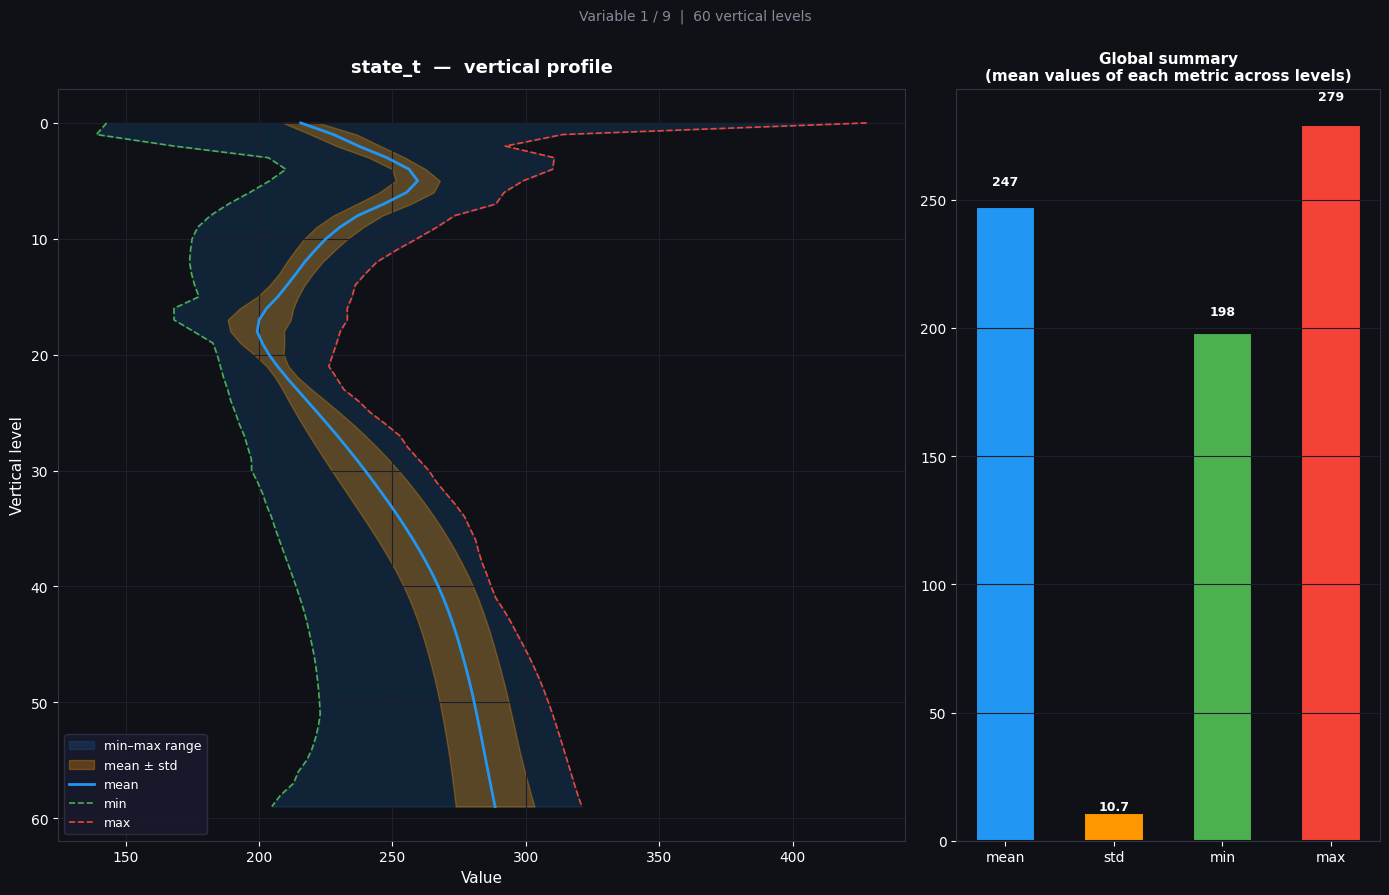

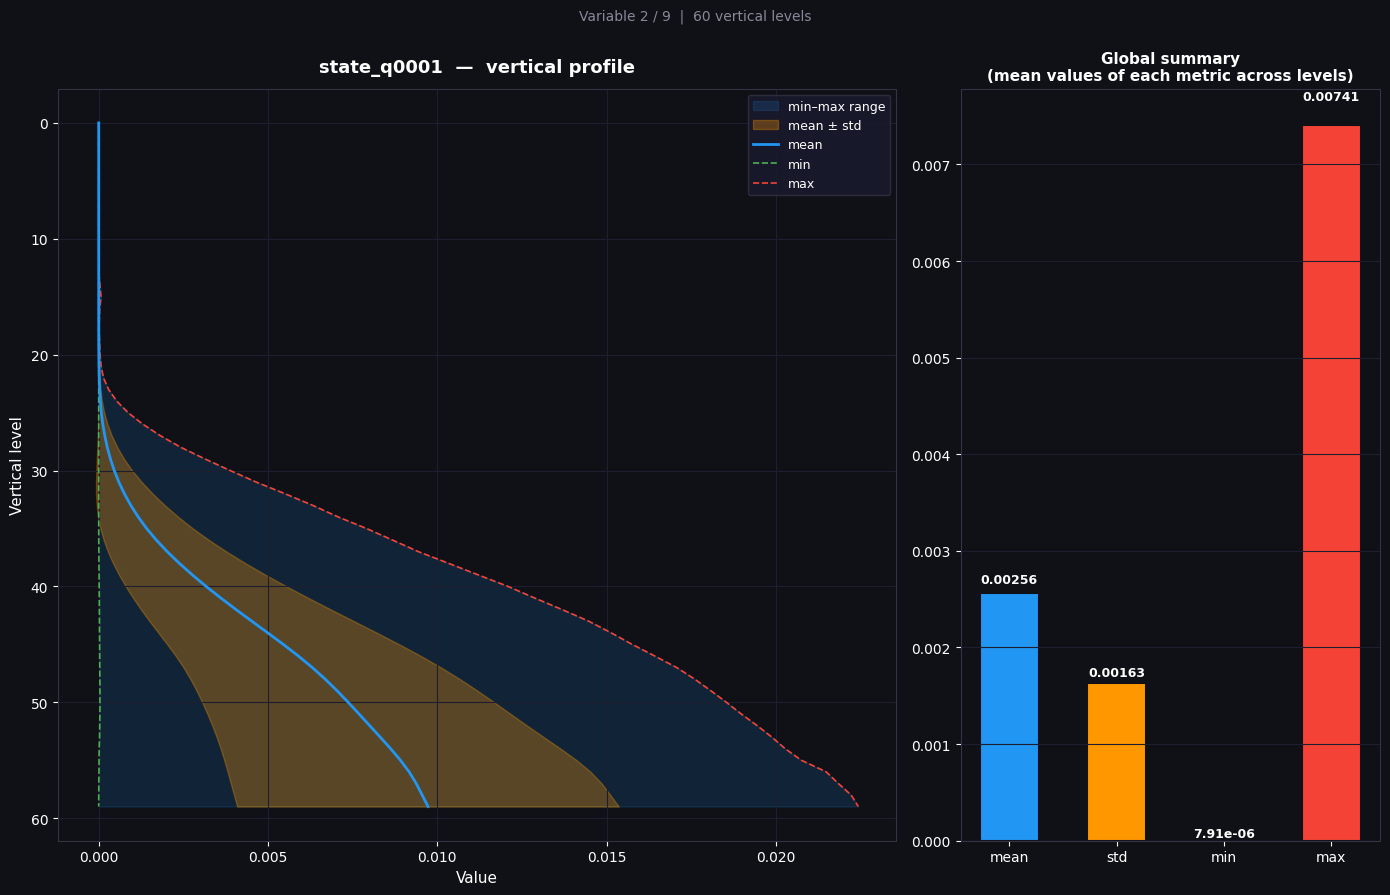

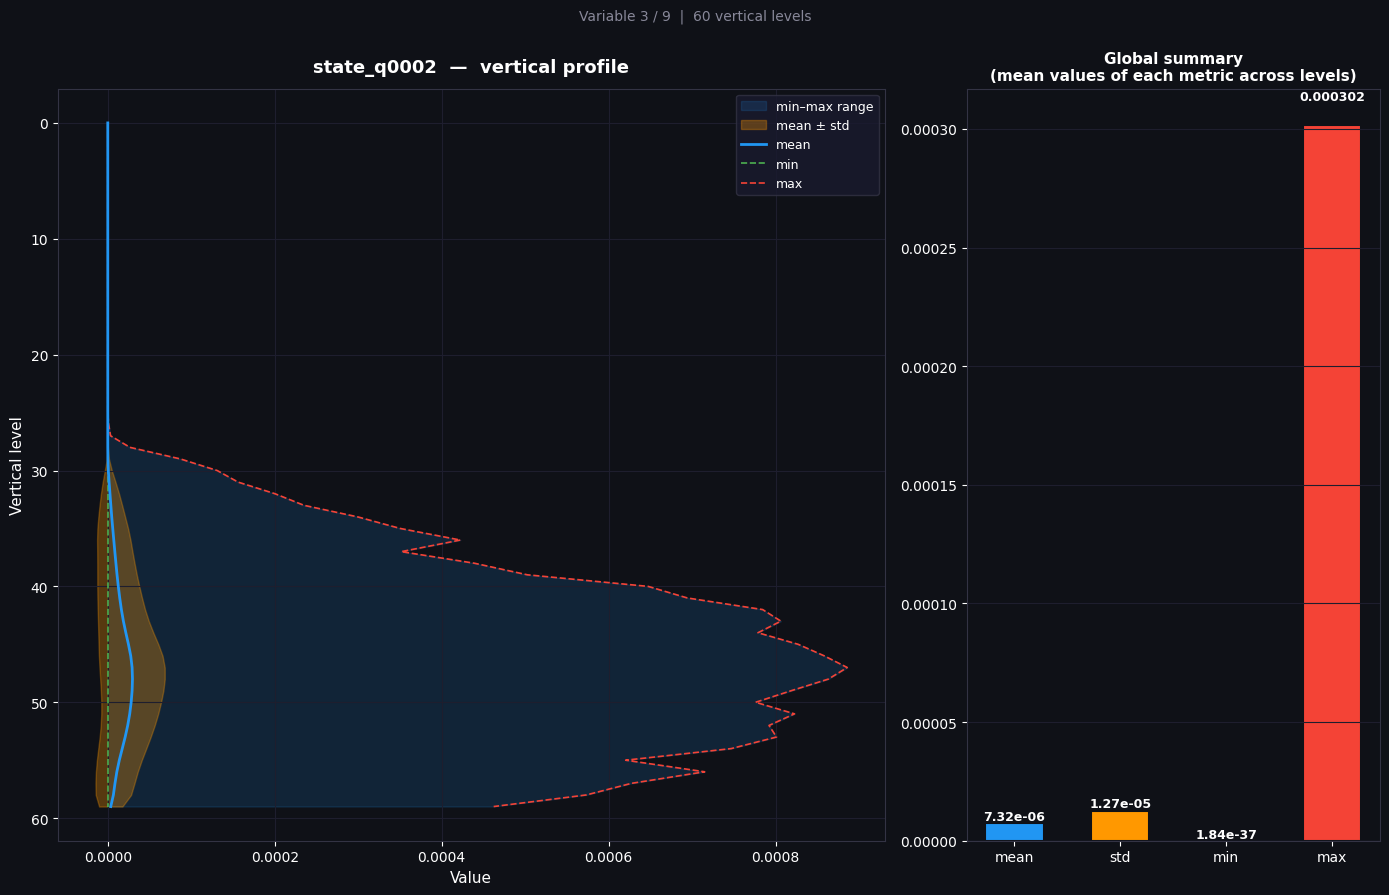

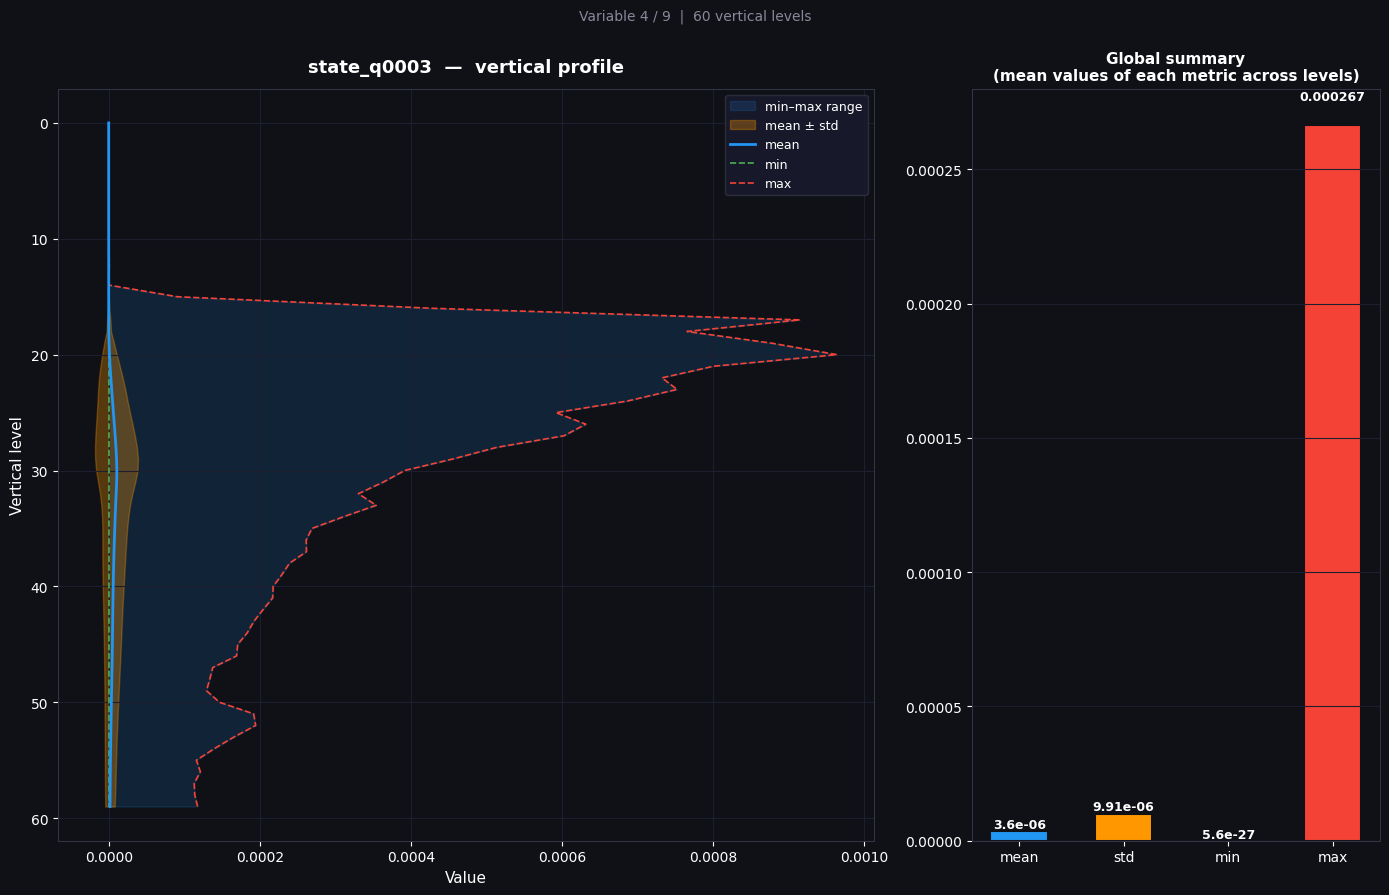

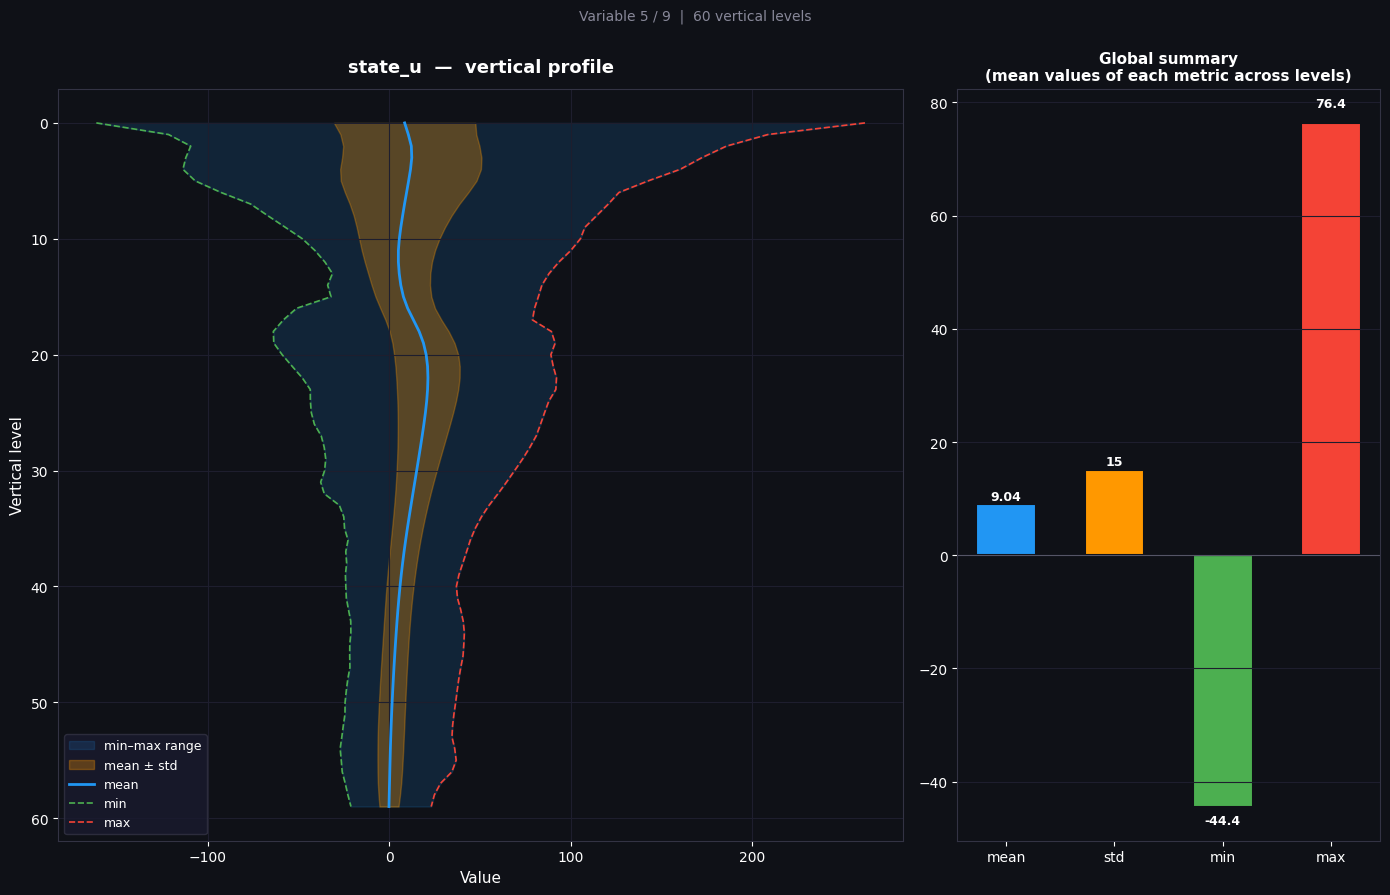

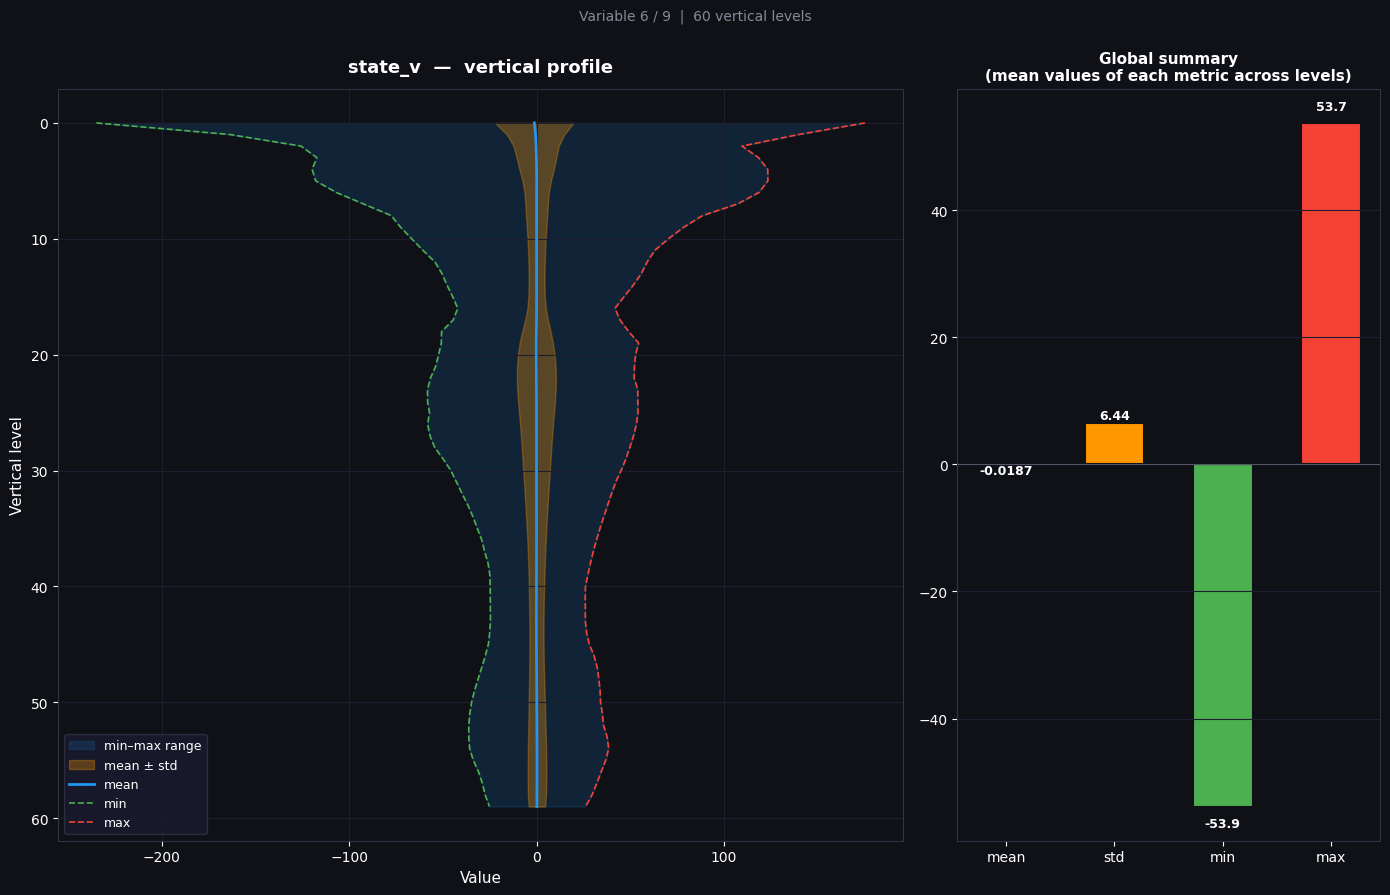

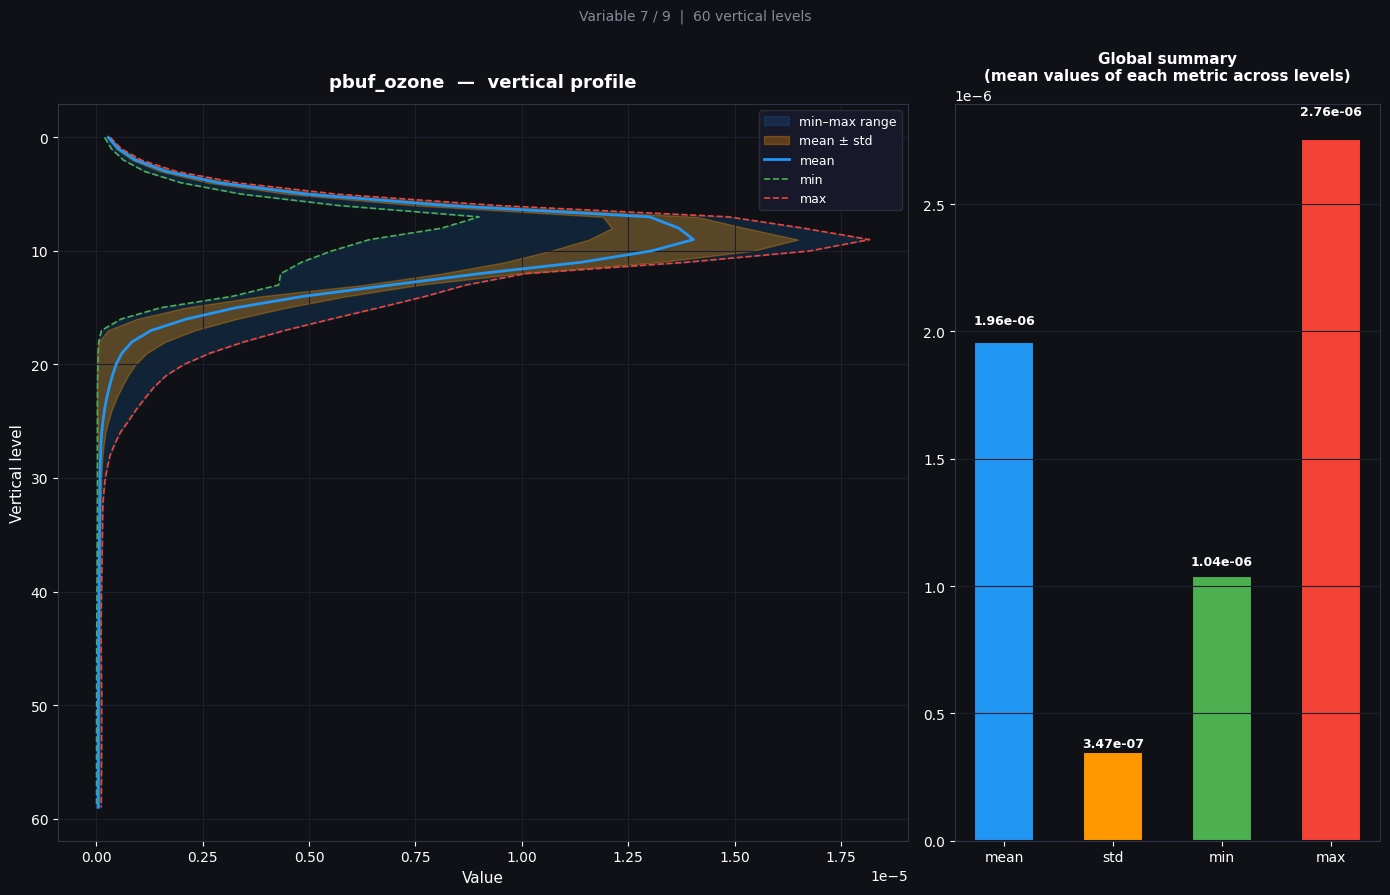

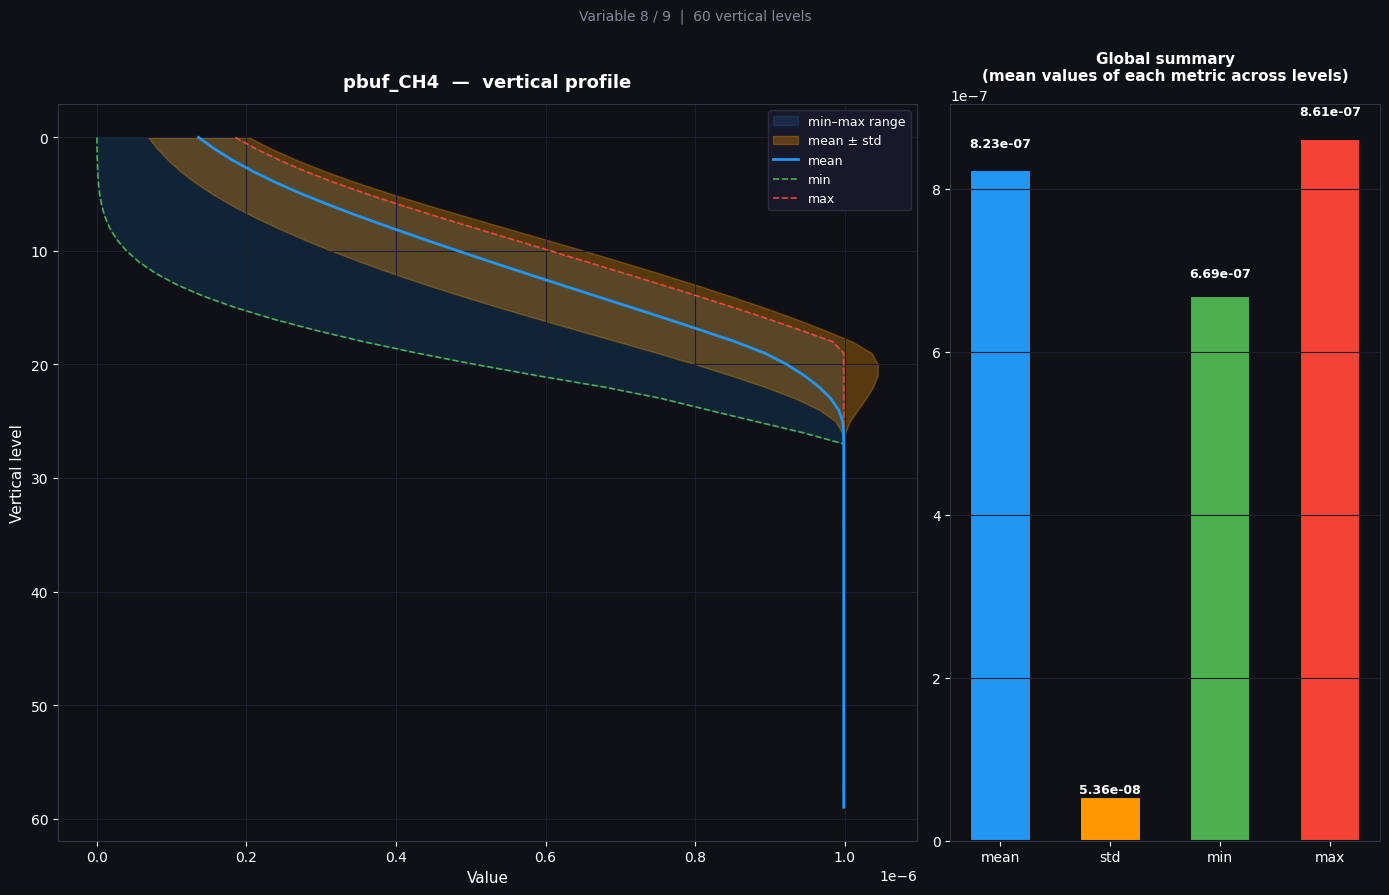

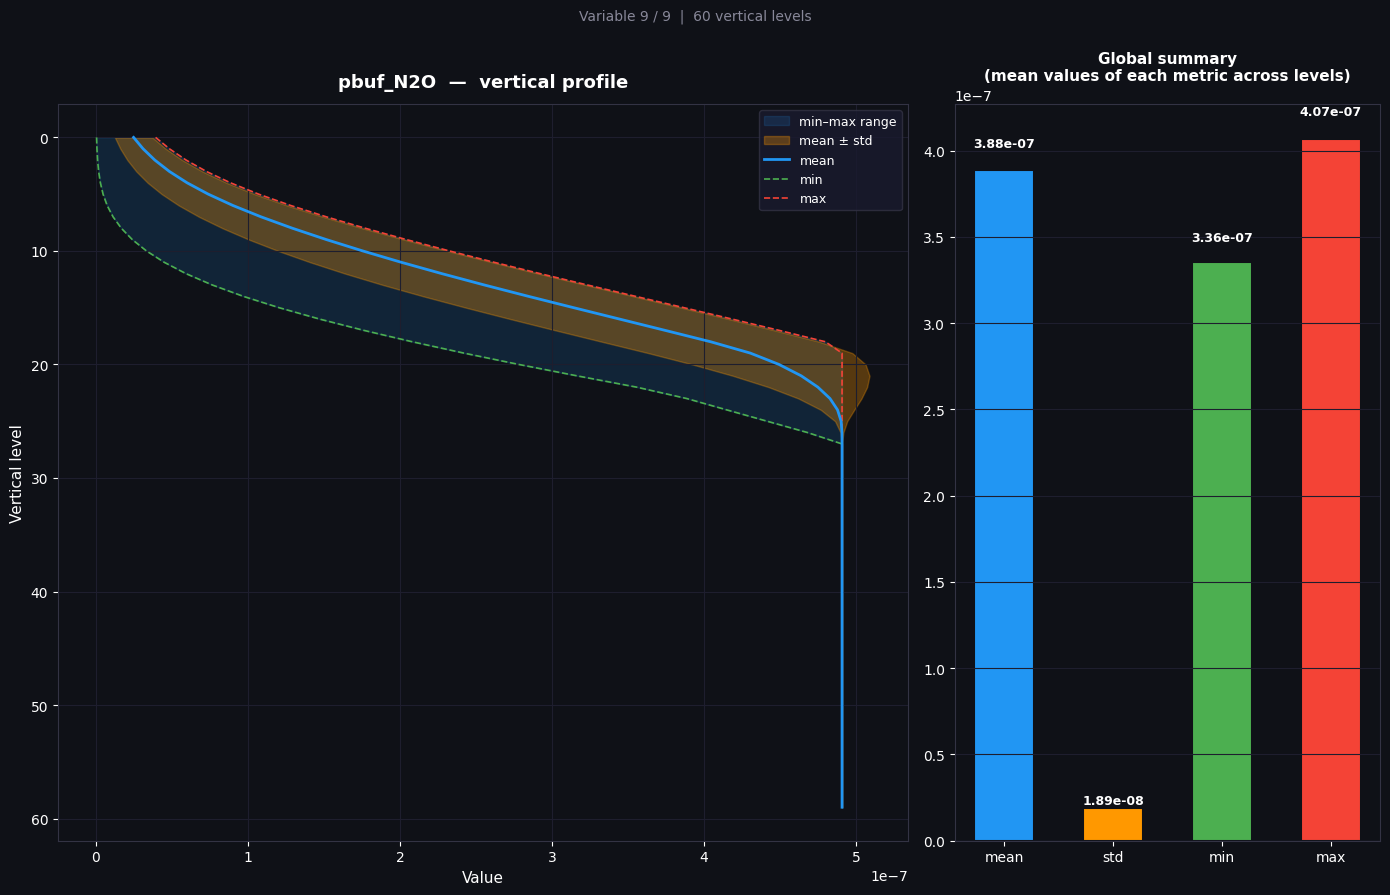

In [61]:
# len(mean_X) - np.mod((len(mean_X)),60)
# len(X_col_series_indices)
# mean_X[X_col_series_indices]
col_name_parent = ['state_t', 'state_q0001', 'state_q0002', 
                   'state_q0003', 'state_u', 'state_v',
                   'pbuf_ozone', 'pbuf_CH4', 'pbuf_N2O'] # These are the basename of the variables with vertical levels

plot_vertical_stats(mean_out=np.reshape(mean_X[X_col_series_indices],(9,60)),
                    std_out=np.reshape(std_X[X_col_series_indices],(9,60)), 
                    min_out=np.reshape(min_X[X_col_series_indices],(9,60)),
                    max_out=np.reshape(max_X[X_col_series_indices],(9,60)), 
                    var_names=col_name_parent, 
                    n_levels=60, 
                    cols_in=None)

## Over the whole column for variables with vertical levels

In [21]:
#----------------------------- Computing global statistics from all chunks ----------------------
select_X_or_Y = 'X'
# select_X_or_Y = 'Y'

#------- Loading chunks
#-mean
mean_X_0 = np.load(f'{base}0/mean_{select_X_or_Y}_vertical_part0.npy') # from notebook 1 output
mean_X_1 = np.load(f'{base}1/mean_{select_X_or_Y}_vertical_part1.npy') # from notebook 2 output
mean_X_2 = np.load(f'{base}2/mean_{select_X_or_Y}_vertical_part2.npy') # from notebook 3 output
mean_X_3 = np.load(f'{base}3/mean_{select_X_or_Y}_vertical_part3.npy') # from notebook 4 output
#-std
std_X_0 = np.load(f'{base}0/std_{select_X_or_Y}_vertical_part0.npy') # from notebook 1 output
std_X_1 = np.load(f'{base}1/std_{select_X_or_Y}_vertical_part1.npy') # from notebook 2 output
std_X_2 = np.load(f'{base}2/std_{select_X_or_Y}_vertical_part2.npy') # from notebook 3 output
std_X_3 = np.load(f'{base}3/std_{select_X_or_Y}_vertical_part3.npy') # from notebook 4 output
#-min
min_X_0 = np.load(f'{base}0/min_{select_X_or_Y}_vertical_part0.npy') # from notebook 1 output
min_X_1 = np.load(f'{base}1/min_{select_X_or_Y}_vertical_part1.npy') # from notebook 2 output
min_X_2 = np.load(f'{base}2/min_{select_X_or_Y}_vertical_part2.npy') # from notebook 3 output
min_X_3 = np.load(f'{base}3/min_{select_X_or_Y}_vertical_part3.npy') # from notebook 4 output
#-max
max_X_0 = np.load(f'{base}0/max_{select_X_or_Y}_vertical_part0.npy') # from notebook 1 output
max_X_1 = np.load(f'{base}1/max_{select_X_or_Y}_vertical_part1.npy') # from notebook 2 output
max_X_2 = np.load(f'{base}2/max_{select_X_or_Y}_vertical_part2.npy') # from notebook 3 output
max_X_3 = np.load(f'{base}3/max_{select_X_or_Y}_vertical_part3.npy') # from notebook 4 output

n0 = 2_522_880
n1 = 2_522_880
n2 = 2_522_880
n3 = 2_522_880

# Weighted mean
mean_X = ((mean_X_0 * n0) + (mean_X_1 * n1) + (mean_X_2 * n2) + (mean_X_3 * n3)) / (n0 + n1+n2 + n3) # <--- final

# Correct global std from both halves
# var = E[X²] - E[X]²  →  E[X²] = var + mean²
ex2_0  = std_X_0**2 + mean_X_0**2
ex2_1  = std_X_1**2 + mean_X_1**2
ex2_2  = std_X_2**2 + mean_X_2**2
ex2_3  = std_X_3**2 + mean_X_3**2

ex2    = ((ex2_0 * n0) + (ex2_1 * n1) + (ex2_2 * n2) + (ex2_3 * n3)) / (n0 + n1+n2 + n3)
std_X  = np.sqrt(ex2 - mean_X**2)                                                                   # <--- final

# min/max: elementwise
min_X  = np.minimum(np.minimum(np.minimum(min_X_0, min_X_1), min_X_2), min_X_3)                    # <--- final
max_X  = np.maximum(np.maximum(np.maximum(max_X_0, max_X_1), max_X_2), max_X_3)                    # <--- final

print("%"*60,f" Files created for variable: {select_X_or_Y }","%"*60)
print("%"*30," Don't forget to save it and run it again for Y or X in case you haven't done it ","%"*30)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%  Files created for variable: Y %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%  Don't forget to save it and run it again for Y or X in case you haven't done it  %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


### Saving global statistics

In [22]:
np.save(f'/kaggle/working/mean_{select_X_or_Y}_NOvertical_levels.npy', mean_X)
np.save(f'/kaggle/working/std_{select_X_or_Y}_NOvertical_levels.npy',  std_X)
np.save(f'/kaggle/working/min_{select_X_or_Y}_NOvertical_levels.npy',  min_X)
np.save(f'/kaggle/working/max_{select_X_or_Y}_NOvertical_levels.npy',  max_X)

In [23]:
!ls

max_X_NOvertical_levels.npy   min_X_NOvertical_levels.npy
max_X_vertical_levels.npy     min_X_vertical_levels.npy
max_Y_NOvertical_levels.npy   min_Y_NOvertical_levels.npy
max_Y_vertical_levels.npy     min_Y_vertical_levels.npy
mean_X_NOvertical_levels.npy  std_X_NOvertical_levels.npy
mean_X_vertical_levels.npy    std_X_vertical_levels.npy
mean_Y_NOvertical_levels.npy  std_Y_NOvertical_levels.npy
mean_Y_vertical_levels.npy    std_Y_vertical_levels.npy


### Making plots of statistics for variables with vertical levels for the column average


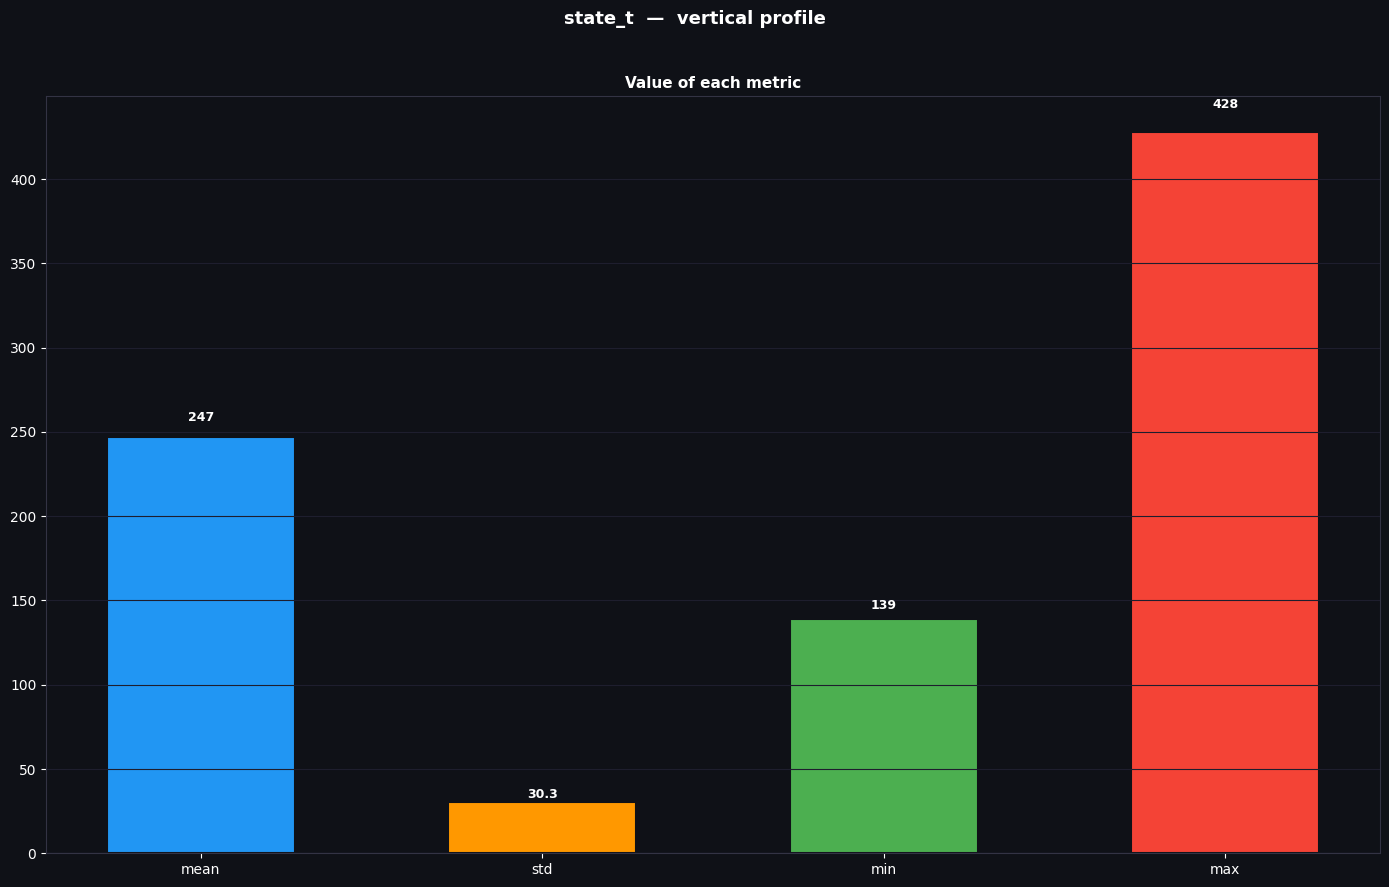

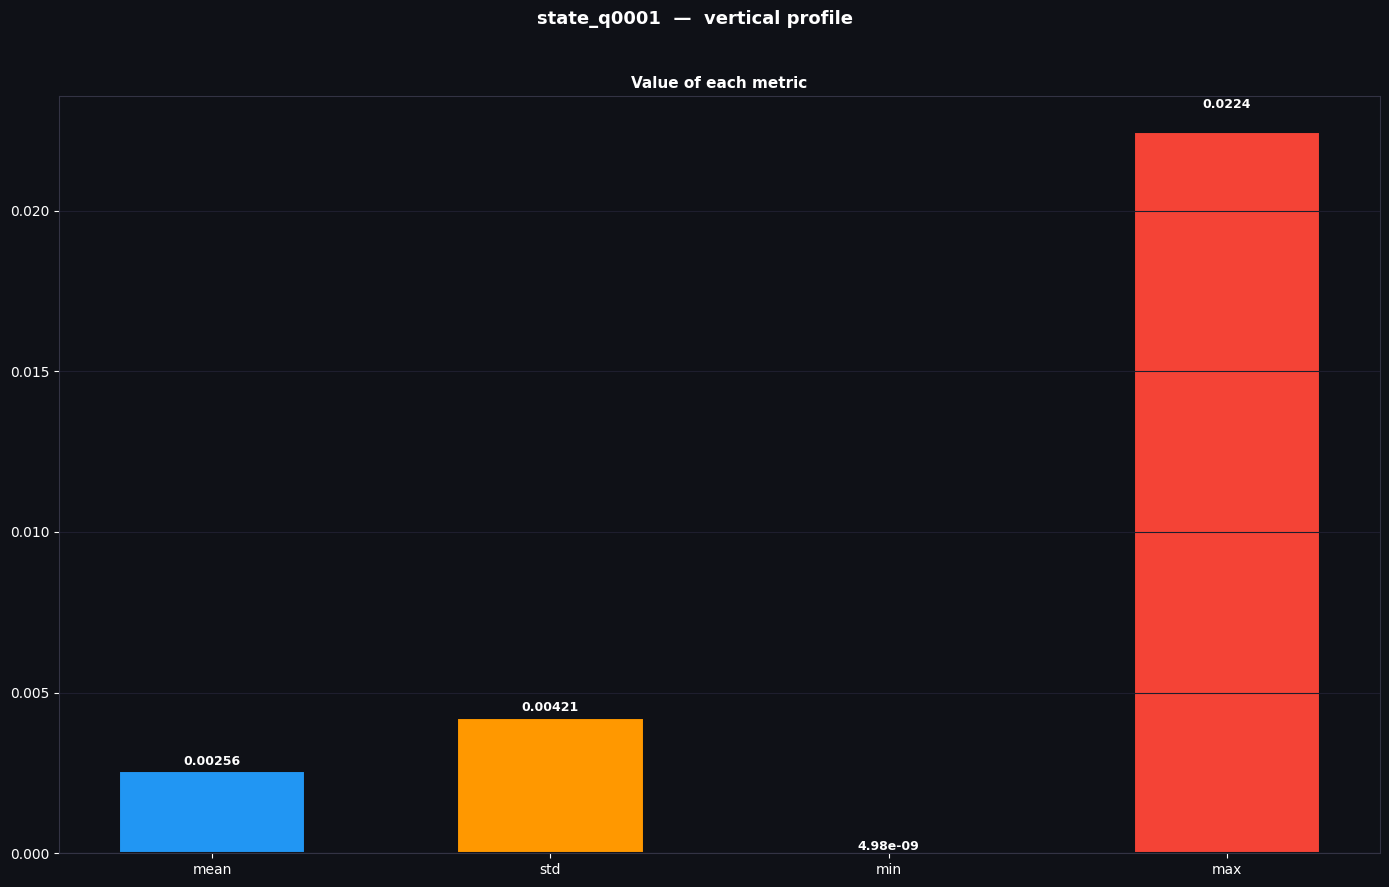

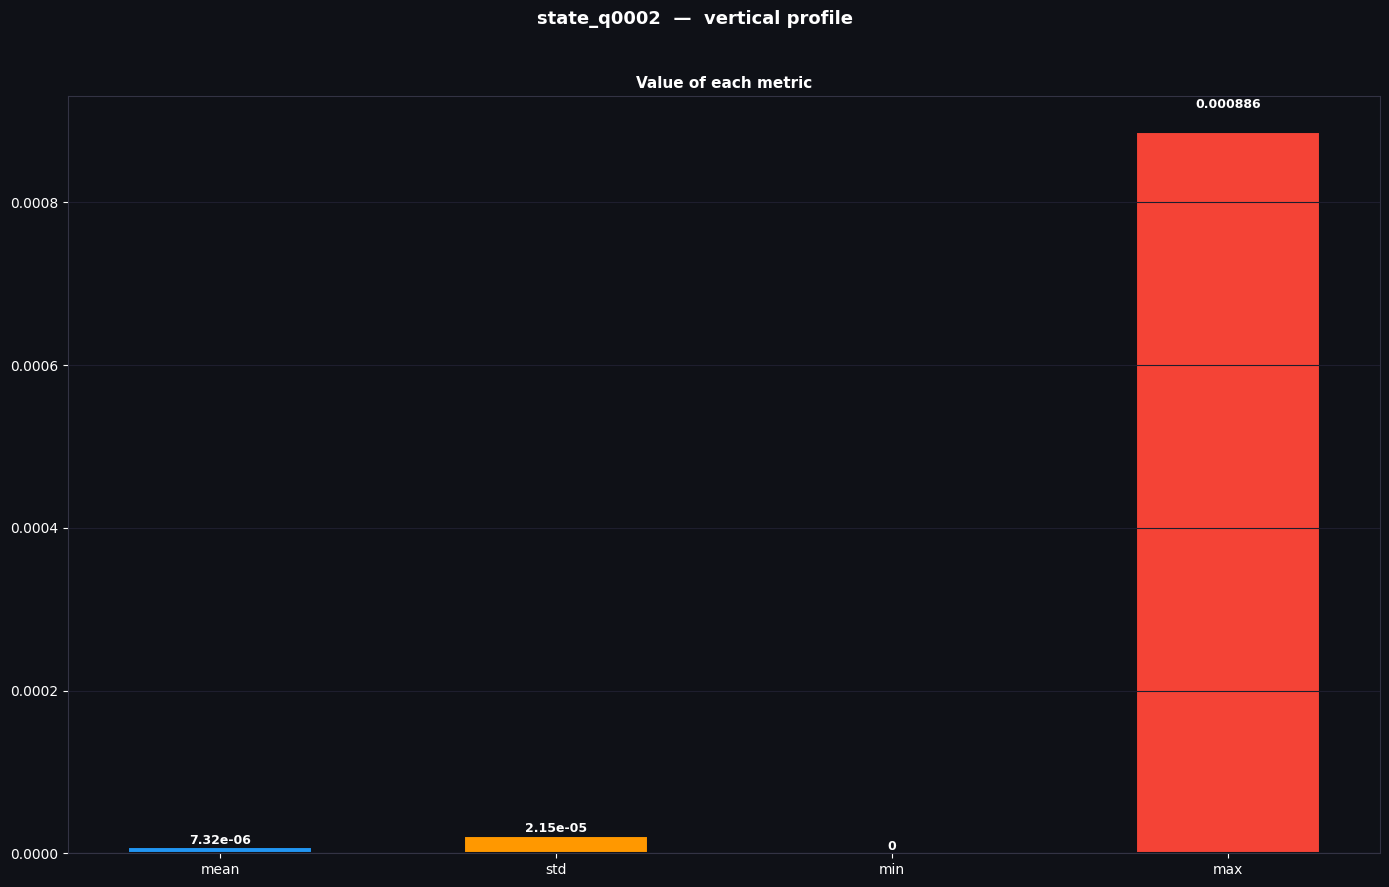

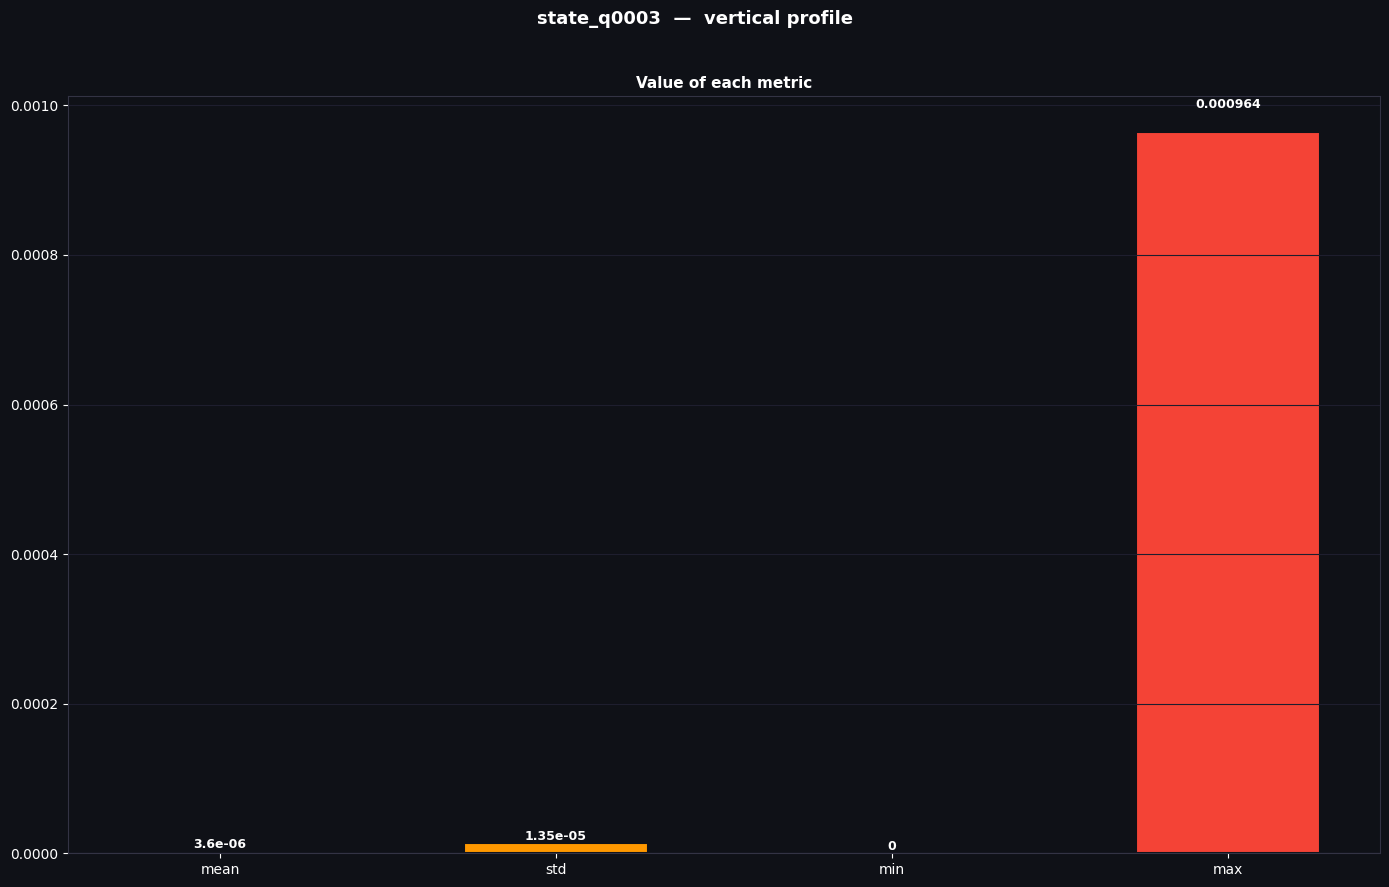

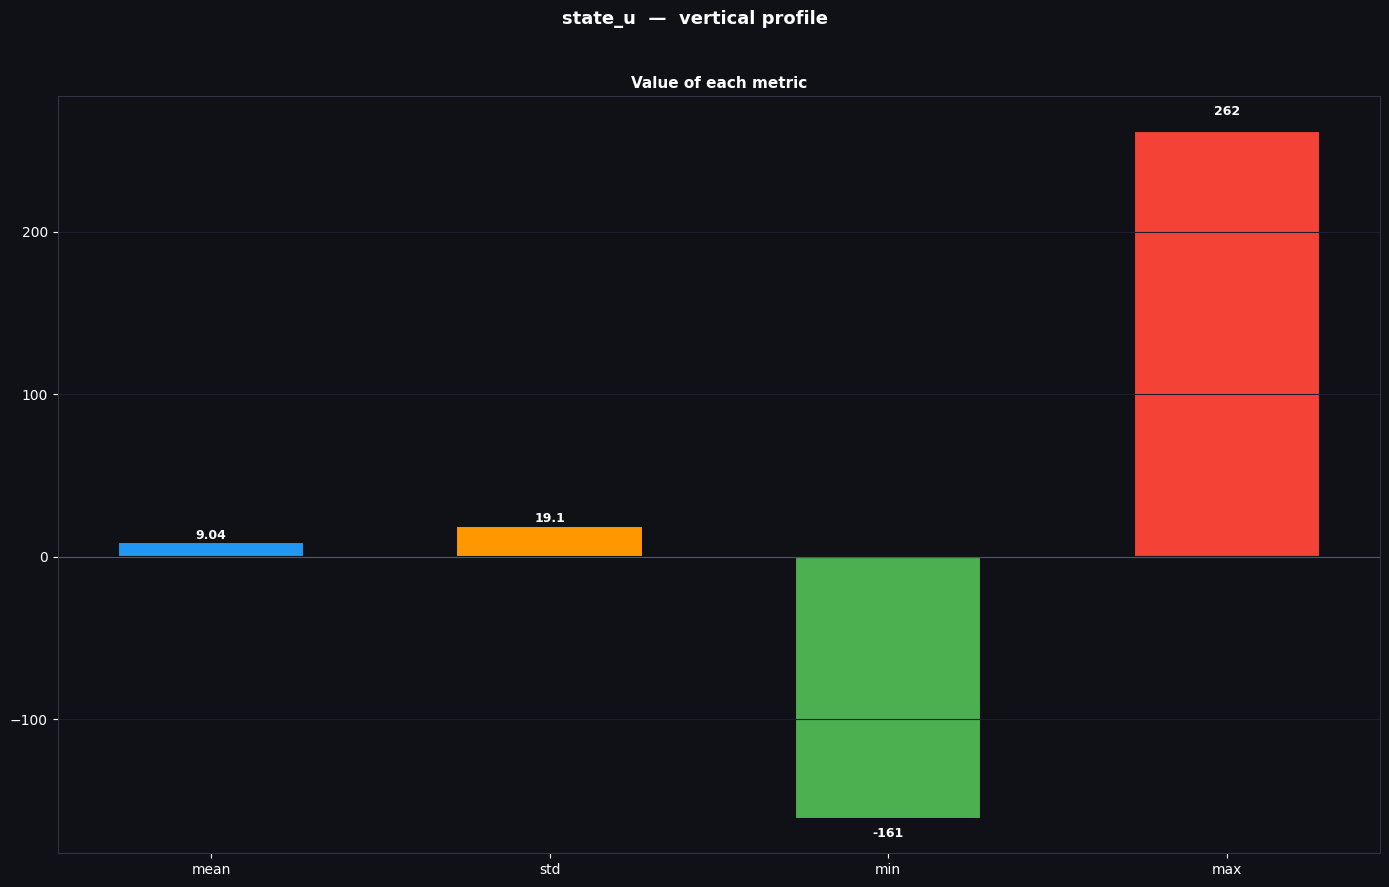

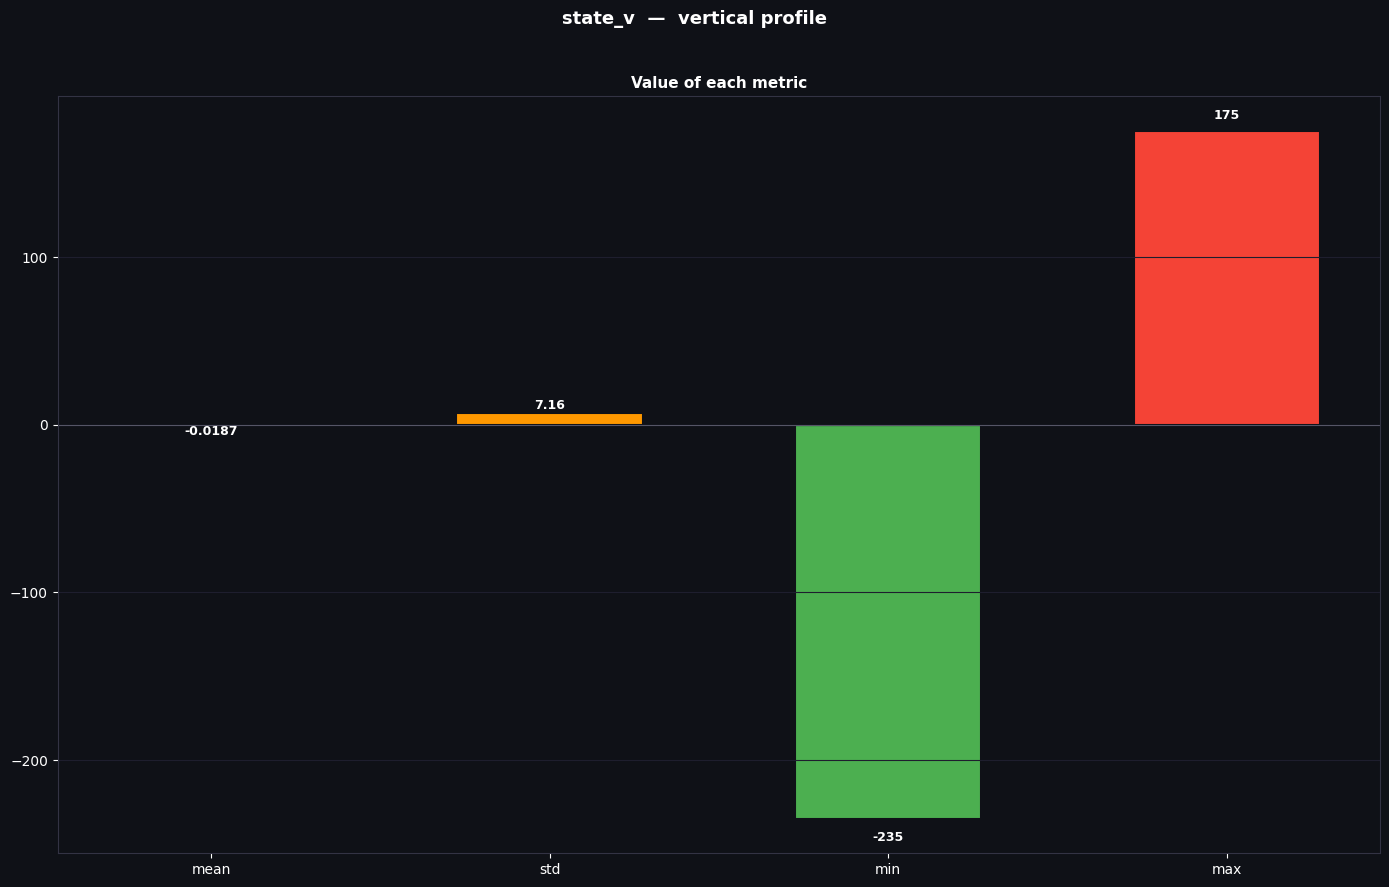

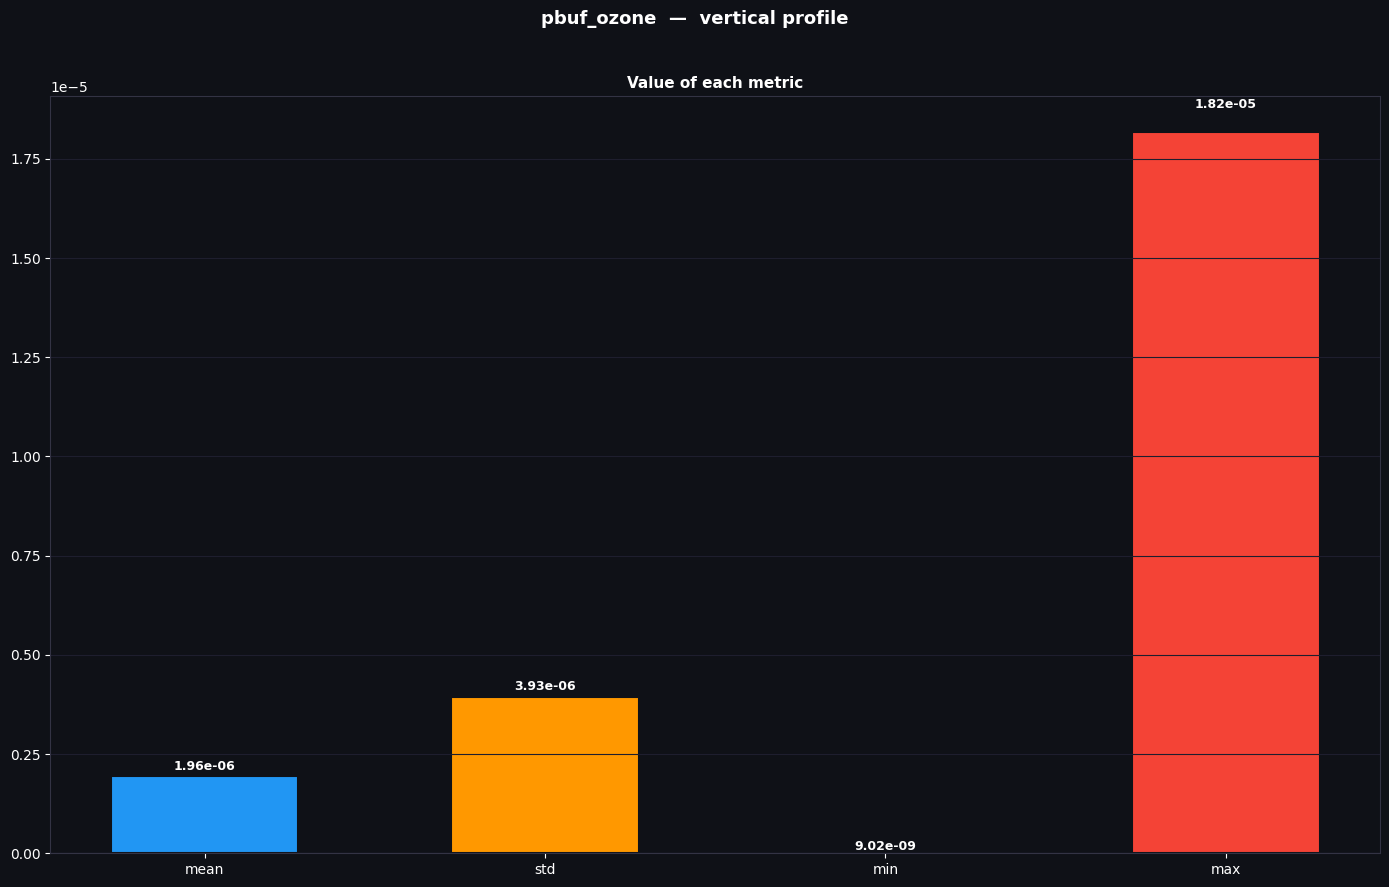

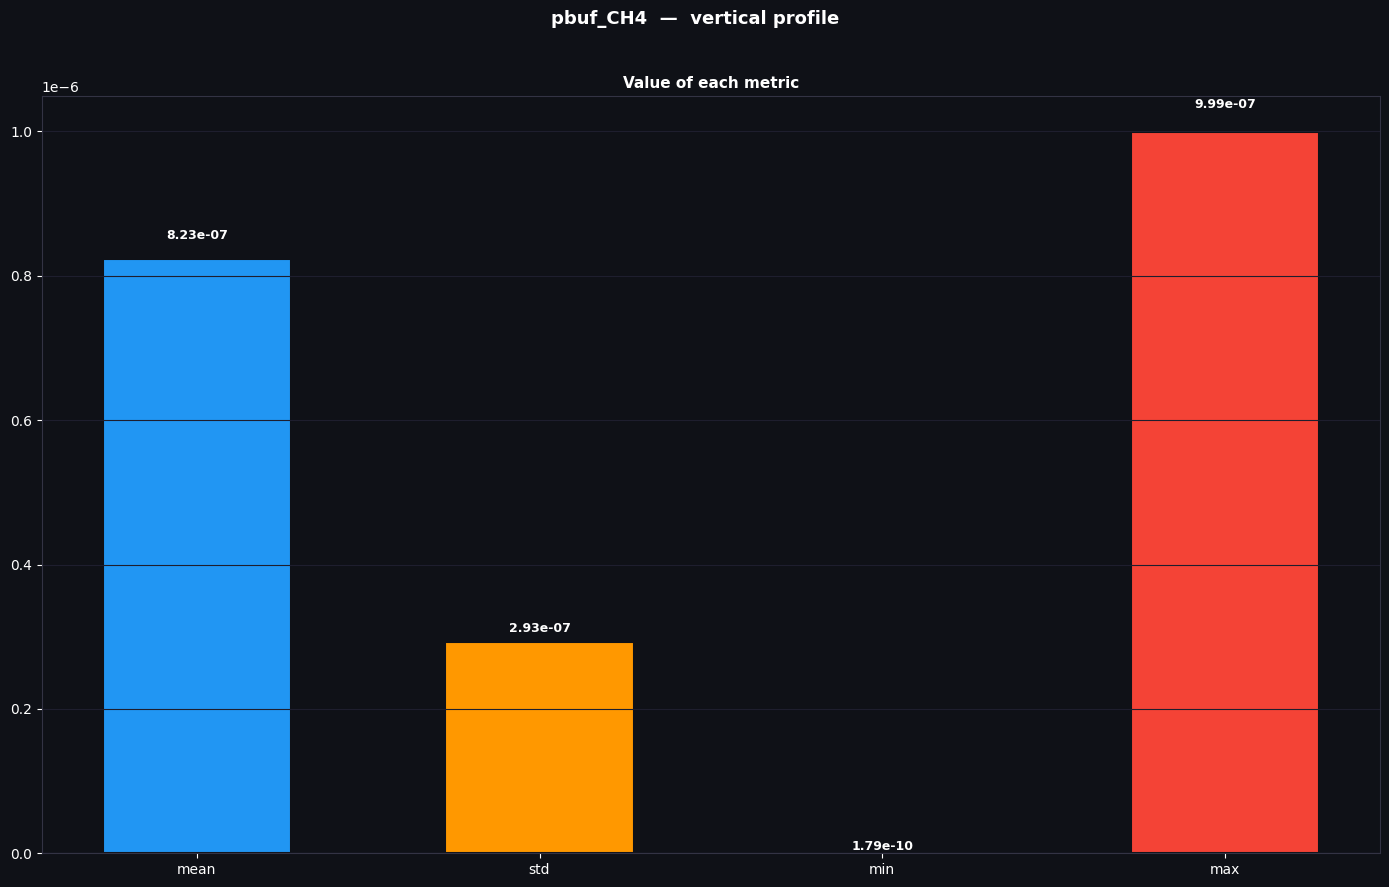

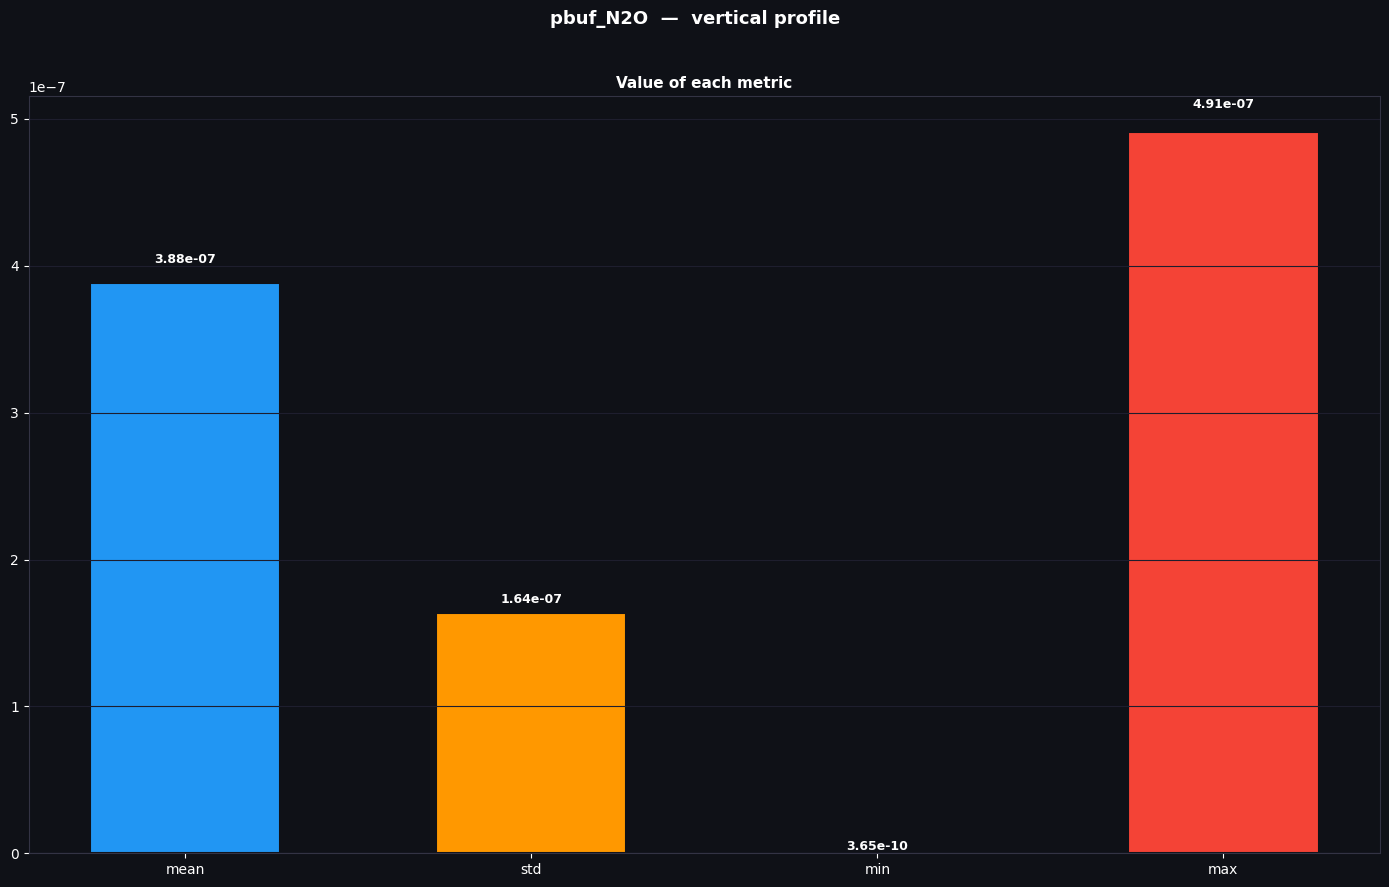

In [80]:
plot_vertical_stats(mean_out=np.reshape(mean_X,(9,1)),
                    std_out=np.reshape(std_X,(9,1)), 
                    min_out=np.reshape(min_X,(9,1)),
                    max_out=np.reshape(max_X,(9,1)), 
                    var_names=col_name_parent, 
                    n_levels=0, 
                    cols_in=None)